# **Lab 3**: Supervised Machine Learning
In this lab you will practice some supervised machine learning: 

- first training and testing a machine learning algorithm to classify hand-written digits; 
- second, using regression to calculate the relationship between a nation's population active on facebook and the number of Nobel prizes its citizens have been awarded.

You will also continue to practice programming in python, which I think we can all agree, is somewhat special.

To pass this lab you must complete all parts marked with a "*". You can do more parts, of course, because in the end that will help you on your project!

*HINT: See code that we have presented in class.*

# Part 1: Classification

# 1.1* 

The following code loads the digits dataset. Determine how many examples there are of each of the digits. Select one of the digits (for instance "8") and show two examples selected at random.


# of samples (0): 178
# of samples (1): 182
# of samples (2): 177
# of samples (3): 183
# of samples (4): 181
# of samples (5): 182
# of samples (6): 181
# of samples (7): 179
# of samples (8): 174
# of samples (9): 180


We decided to show 8:


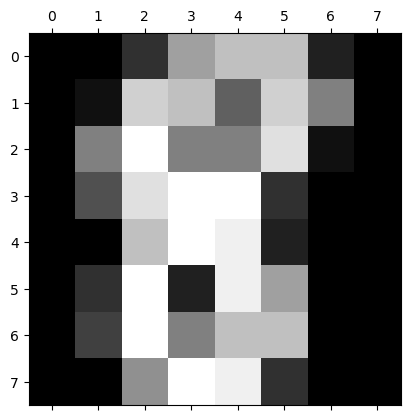

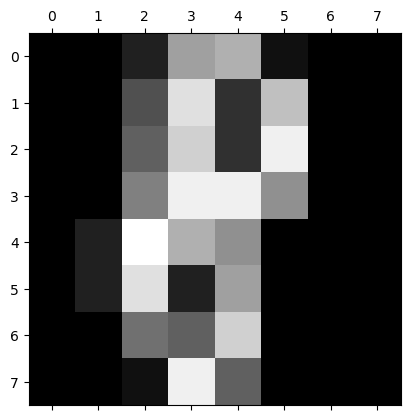

In [17]:
from sklearn import datasets
import numpy as np
%matplotlib inline 
import matplotlib.pyplot as plt
digits = datasets.load_digits()
import random

for i in digits.target_names:
    print(f"# of samples ({i}): {np.size(np.where(digits.target == i)[0])}")

print(f"\n\nWe decided to show 8:")
eights_indices = np.where(digits.target == 8)[0]

plt.matshow(digits.images[random.choice(eights_indices)], cmap='gray')
plt.matshow(digits.images[random.choice(eights_indices)], cmap='gray')
plt.show()

# 1.2* 

Using the appropriate sklearn routine, split the digits dataset into a  training set and a test set of the same size.

In [18]:
from sklearn import model_selection

x = digits.data
y = digits.target

x_train, x_test, y_train, y_test = model_selection.train_test_split(x, y, train_size=0.5, random_state=7)
#we chose the random state because both of us are born in July

print(f"X: {x_train.shape, x_test.shape}")
print(f"Y: {y_train.shape, y_test.shape}")

X: ((898, 64), (899, 64))
Y: ((898,), (899,))


# 1.3*

With your datasets, now train and test a kNN model for k in {1, 2, ..., 10}, and plot a figure showing the accuracy on the training set and on the test set as a function of k.

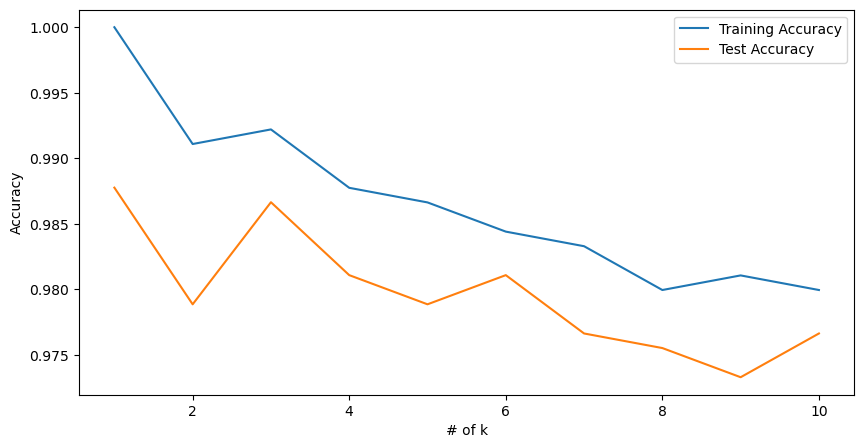

In [19]:
from sklearn import neighbors

k_s = range(1, 11)

training_results = []
test_results = []

for k in k_s:
    kNN = neighbors.KNeighborsClassifier(n_neighbors=k)
    kNN.fit(x_train, y_train)

    training_results.append(kNN.score(x_train, y_train)) #score returns accuracy
    test_results.append(kNN.score(x_test, y_test))

# -----
plt.figure(figsize=(10, 5))
plt.plot(k_s, training_results, label='Training Accuracy')
plt.plot(k_s, test_results, label='Test Accuracy')
plt.xlabel('# of k')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 1.4*

Using your result from 1.3, which values of k can you observe overfitting? Which value of k is the best and why?

**Answer**: We would say from k= 1, 2, because the difference in accuracy between the test and training data is the greatest amongst all k's, and because we can observe unreasonably high accuracy (99-100%).

# 1.5* 

Train a kNN classifier with your best value of k, and display the confusion table of the training classifer applied to the testing dataset. (Hint: see part on confusion matrices in Chapter 5 of the course book.)

In [27]:
def print_cm(cm, labels, hide_zeroes=False, hide_diagonal=False, hide_threshold=None):
    """pretty print for confusion matrixes"""
    """taken from https://gist.github.com/zachguo/10296432"""
    columnwidth = max([len(x) for x in labels] + [5])  # 5 is value length
    empty_cell = " " * columnwidth
    
    # Begin CHANGES
    fst_empty_cell = (columnwidth-3)//2 * " " + "t\p" + (columnwidth-3)//2 * " "
    
    if len(fst_empty_cell) < len(empty_cell):
        fst_empty_cell = " " * (len(empty_cell) - len(fst_empty_cell)) + fst_empty_cell
    # Print header
    print("    " + fst_empty_cell, end=" ")
    # End CHANGES
    
    for label in labels:
        print("%{0}s".format(columnwidth) % label, end=" ")
        
    print()
    # Print rows
    for i, label1 in enumerate(labels):
        print("    %{0}s".format(columnwidth) % label1, end=" ")
        for j in range(len(labels)):
            cell = "%{0}.2f".format(columnwidth) % cm[i, j]
            if hide_zeroes:
                cell = cell if float(cm[i, j]) != 0 else empty_cell
            if hide_diagonal:
                cell = cell if i != j else empty_cell
            if hide_threshold:
                cell = cell if cm[i, j] > hide_threshold else empty_cell
            print(cell, end=" ")
        print()
        
# add your code below
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

kNN = neighbors.KNeighborsClassifier(n_neighbors=6)

y_train_pred = cross_val_predict(kNN, x_train, y_train, cv=5)

# x = data, y = target

cm = confusion_matrix(y_train, y_train_pred)
print_cm(cm, digits.target_names.astype(str))



     t\p      0     1     2     3     4     5     6     7     8     9 
        0 83.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
        1  0.00 92.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00 
        2  0.00  1.00 86.00  0.00  0.00  0.00  0.00  1.00  1.00  0.00 
        3  0.00  0.00  0.00 95.00  0.00  0.00  0.00  1.00  0.00  0.00 
        4  0.00  0.00  0.00  0.00 93.00  0.00  0.00  2.00  0.00  0.00 
        5  0.00  0.00  0.00  0.00  1.00 95.00  1.00  0.00  0.00  2.00 
        6  1.00  0.00  0.00  0.00  0.00  0.00 88.00  0.00  0.00  0.00 
        7  0.00  0.00  0.00  0.00  0.00  0.00  0.00 88.00  0.00  0.00 
        8  0.00  4.00  0.00  0.00  0.00  0.00  1.00  0.00 68.00  1.00 
        9  0.00  1.00  0.00  1.00  1.00  2.00  0.00  0.00  1.00 86.00 


# 1.6*

From your confusion table:
- which two digits are confused the most? Try to explain why.
- which digit(s) is(are) the hardest to identify? Try to explain why.
- which digit(s) is(are) the easiest to identify? Try to explain why.

**Answer**: 
- 8's are confused with 1's the most, probably because a poorly written, low resolution 8 might look like a single stroke. And thats represented in the amount of false positives in (8,1).
- 8's are hardest to identify it seems, because it has the lowest recall rate: TP/(TP+FN) = 68/(68+(4+1+1)) ~= 91.9%
- 0's are easiest to identify, with no FNs at all, giving a 100% recall rate.



# 1.7 

Using the dataset split from 1.2, train and test a different classifer, and create a confusion table. 

In [58]:
# add your code below

# x_train, x_test, y_train, y_test

from sklearn.svm import SVC
#clf = neighbors.KNeighborsClassifier(n_neighbors=6)
clf = SVC(kernel='rbf', gamma=0.001, C=100000090000000)

clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
cm = confusion_matrix(y_test, y_pred)

print_cm(cm, digits.target_names.astype(str))

     t\p      0     1     2     3     4     5     6     7     8     9 
        0 94.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00 
        1  0.00 89.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
        2  0.00  0.00 88.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00 
        3  0.00  0.00  0.00 86.00  0.00  0.00  0.00  0.00  0.00  1.00 
        4  0.00  0.00  0.00  0.00 86.00  0.00  0.00  0.00  0.00  0.00 
        5  0.00  0.00  0.00  0.00  0.00 83.00  0.00  0.00  0.00  0.00 
        6  0.00  0.00  0.00  0.00  0.00  0.00 92.00  0.00  0.00  0.00 
        7  0.00  0.00  0.00  0.00  0.00  0.00  0.00 91.00  0.00  0.00 
        8  0.00  2.00  0.00  0.00  0.00  0.00  0.00  1.00 97.00  0.00 
        9  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00 87.00 


# 1.8

Compare the confusion tables in 1.7 and 1.5. Was there an improvement anywhere? Was there a deterioration?

**Answer**: Seems to be an overall improvement. Higher recall rates and higher amounts of true positives. Though it seems 3 and 8 have switched places, when it comes to amounts of true positives.

# Part 2: Regression

# 2.1* 

Load the dataset "SweetFaceNobel.txt". The columns of this dataset mean the following: Name of country, number of nobel prizes awarded to citizens of that country, the population of that country, per capita consumption of chocholate in that country (kg), and the number of citizens of that country that have a facebook account. Make a scatter plot of the per capita Nobel Prizes versus the percentage of facebook users of a country.


In [22]:
# add your code below 


# 2.2* 

Find the parameters of the line $y = mx + b$ fit to this data by the method of least squares, where $x$ is the percentage of people on fb, and $y$ is the per capita number of Nobel prizes.


In [23]:
# add your code below


# 2.3* 

According to your model:
- For a country with a population of 10 million, how many more Nobel prizes should it expect to win if the percentage of that country on facebook increases 10 percentage points?
- What is the maximum percentage of facebook users of a country where the number of Nobel prizes is negative?

**Answer**:


# 2.4* 

Find the parameters of the model $y = m_1x^2 + m_2x + b$ fit to this data by the method of least squares.


In [24]:
# add your code below


# 2.5* 

Explain: 
- Which of the two models you fit to the data makes the most sense, i.e., the model in 2.3 and the model in 2.4.
- How you would respond to the claim that increasing facebook activity in a country increases its scientific excellence?

**Answer**:


# 2.6

Find the parameters of the least squares plane ($y = m_1x + m_2z + b$) fit to this data, where $x$ is the percentage of facebook users of a country, and $z$ is the chocolate consumption per capita.


In [25]:
# add your code below


# 2.7

Find the parameters of the least squares surface ($y = m_1x + m_2x^2 + m_3z + m_4xz + b$) fit to this data, where $x$ is the percentage of facebook users of a country, and $z$ is the chocolate consumption per capita.


In [26]:
# add your code below
